In [1]:
pip install flwr torch numpy

  Using cached protobuf-4.25.7-cp38-cp38-win_amd64.whl.metadata (541 bytes)
Using cached protobuf-4.25.7-cp38-cp38-win_amd64.whl (413 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 3.20.3
    Uninstalling protobuf-3.20.3:
      Successfully uninstalled protobuf-3.20.3
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [5]:
from model import LSTMIDS
import torch
import flwr as fl
import crypten
from crypten.config import cfg
from omegaconf import OmegaConf

# ✅ Fix config for CrypTen
cfg.mpc = OmegaConf.create({"provider": "basic"})
cfg.encoder = OmegaConf.create({"precision_bits": 16})
cfg.debug = OmegaConf.create({"validation_mode": False})
cfg.cuda = False

# ✅ Windows-safe initialization
crypten.init_thread(rank=0, world_size=1)

# Define SMPC strategy
class SecureFedAvg(fl.server.strategy.FedAvg):
    def aggregate_fit(self, rnd, results, failures):
        if failures:
            print(f"Round {rnd} - Failures: {failures}")

        encrypted_params = []

        for _, fit_res in results:
            client_params = [torch.tensor(nd, dtype=torch.float32) for nd in fl.common.parameters_to_ndarrays(fit_res.parameters)]
            encrypted_client_params = [crypten.cryptensor(p) for p in client_params]
            encrypted_params.append(encrypted_client_params)

        num_clients = len(encrypted_params)
        encrypted_avg_params = []

        for param_idx in range(len(encrypted_params[0])):
            summed = encrypted_params[0][param_idx]
            for client_idx in range(1, num_clients):
                summed += encrypted_params[client_idx][param_idx]
            avg = summed / num_clients
            encrypted_avg_params.append(avg.get_plain_text())

        aggregated_parameters = fl.common.ndarrays_to_parameters(
            [p.detach().numpy() for p in encrypted_avg_params]
        )
        return aggregated_parameters, {}

# Init model + Flower strategy
model = LSTMIDS(input_size=25)
initial_parameters = fl.common.ndarrays_to_parameters(
    [val.cpu().detach().numpy() for val in model.parameters()]
)

strategy = SecureFedAvg(
    fraction_fit=1.0,
    min_fit_clients=3,
    min_available_clients=3,
    initial_parameters=initial_parameters
)

fl.server.start_server(
    server_address="0.0.0.0:8080",
    config=fl.server.ServerConfig(num_rounds=50),
    strategy=strategy
)


INFO:root:==================
INFO:root:InProcessCommunicator with rank 0
INFO:root:==================
INFO:root:World size = 1
C:\Users\saipr\anaconda3\envs\crypten_env\lib\site-packages\torch\nn\modules\rnn.py:62: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "
INFO :      Starting Flower server, config: num_rounds=50, no round_timeout
INFO:flwr:Starting Flower server, config: num_rounds=50, no round_timeout
INFO :      Flower ECE: gRPC server running (50 rounds), SSL is disabled
INFO:flwr:Flower ECE: gRPC server running (50 rounds), SSL is disabled
INFO :      [INIT]
INFO:flwr:[INIT]
INFO :      Using initial global parameters provided by strategy
INFO:flwr:Using initial global parameters provided by strategy
INFO :      Starting evaluation of initial global parameters
INFO:flwr:Starting evaluation o

History (loss, distributed):
	round 1: 242.7598245347986
	round 2: 215.86393281596284
	round 3: 202.3923700115742
	round 4: 191.81496136595229
	round 5: 186.66059906306185
	round 6: 174.91518628717776
	round 7: 166.764395321154
	round 8: 165.1724806380178
	round 9: 152.6610815363633
	round 10: 155.46947603390217
	round 11: 141.0065766707897
	round 12: 135.60586459231186
	round 13: 144.14476589711055
	round 14: 128.1695352473832
	round 15: 126.84585944566611
	round 16: 124.3037218435221
	round 17: 119.41938197695329
	round 18: 118.96359366113187
	round 19: 122.15857366168576
	round 20: 118.34849923409698
	round 21: 154.71510720456072
	round 22: 114.78712141393004
	round 23: 112.88594668305296
	round 24: 109.06886276797245
	round 25: 108.56078190746848
	round 26: 107.99352342675631
	round 27: 108.59429268663064
	round 28: 106.36423287452824
	round 29: 105.66877334919877
	round 30: 106.72276819571134
	round 31: 116.48801796298937
	round 32: 105.07565782405082
	round 33: 103.76592076507863

In [11]:
import pandas as pd

# Load the CSV
df = pd.read_csv("C:/Users/saipr/OneDrive/Documents/Deep Learning/FL-IDS Project/client_metrics_rounds_1.csv")

# Preview the first few rows
print(df.head())
print(df["Round"].value_counts().sort_index())


   Round  Accuracy  Precision    Recall        F1
0      1  0.974916   0.948857  0.980725  0.964528
1      1  0.974197   0.947942  0.979371  0.963400
2      1  0.974187   0.947985  0.979174  0.963327
3      2  0.979557   0.960572  0.981497  0.970922
4      2  0.978665   0.959541  0.979786  0.969558
Round
1     3
2     3
3     3
4     3
5     3
6     3
7     3
8     3
9     3
10    3
11    3
12    3
13    3
14    3
15    3
16    3
17    3
18    3
19    3
20    3
21    3
22    3
23    3
24    3
25    3
26    3
27    3
28    3
29    3
30    3
31    3
32    3
33    3
34    3
35    3
36    3
37    3
38    3
39    3
40    3
41    3
42    3
43    3
44    3
45    3
46    3
47    3
48    3
49    3
50    3
Name: count, dtype: int64


C:\Users\saipr\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
C:\Users\saipr\AppData\Local\Temp\ipykernel_18084\3952309093.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df, x="Round", y="F1", estimator='mean', ci=None)


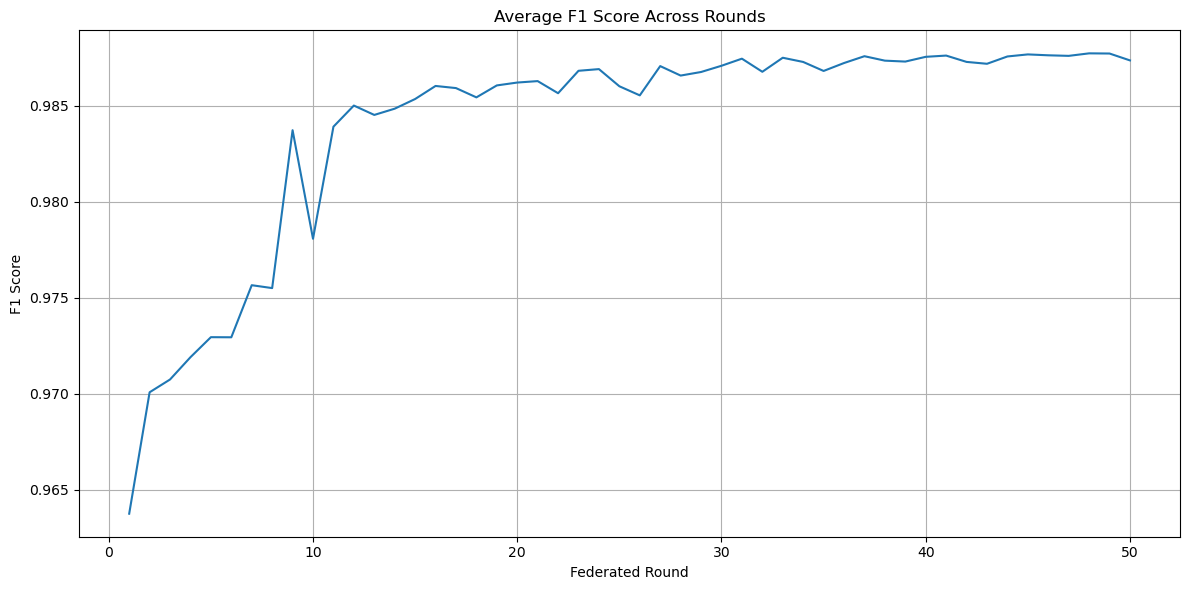

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot F1-score across rounds
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="Round", y="F1", estimator='mean', ci=None)
plt.title("Average F1 Score Across Rounds")
plt.ylabel("F1 Score")
plt.xlabel("Federated Round")
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\saipr\AppData\Local\Temp\ipykernel_18084\1044261691.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df, x="Round", y="Recall", estimator='mean', ci=None)


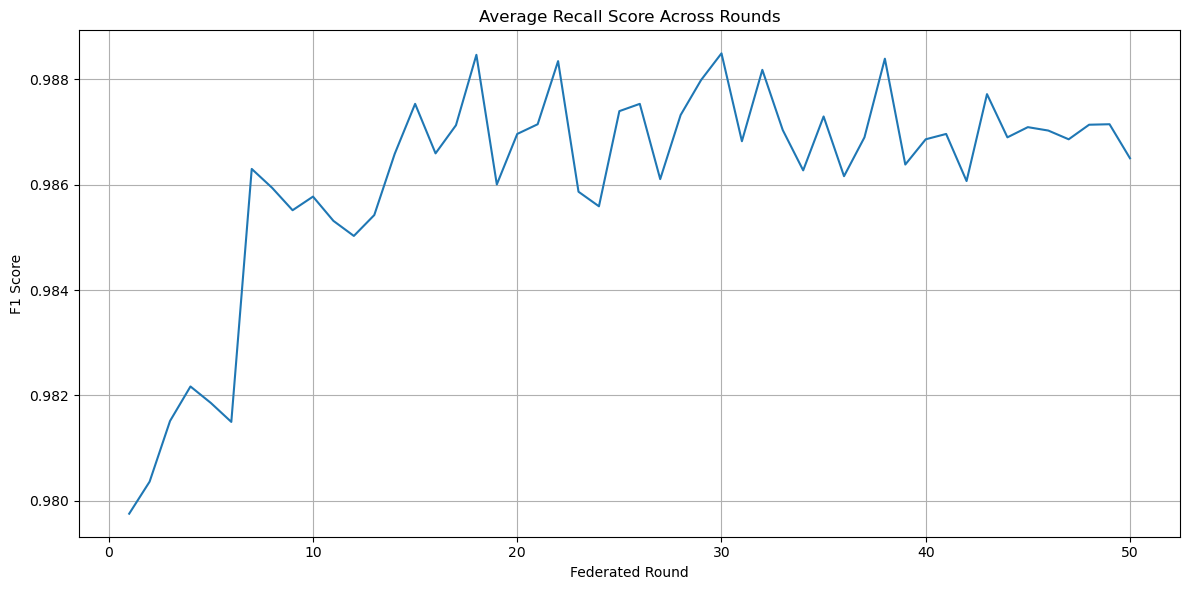

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot F1-score across rounds
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="Round", y="Recall", estimator='mean', ci=None)
plt.title("Average Recall Score Across Rounds")
plt.ylabel("F1 Score")
plt.xlabel("Federated Round")
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\saipr\AppData\Local\Temp\ipykernel_18084\3381257194.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df, x="Round", y="Accuracy", estimator='mean', ci=None)


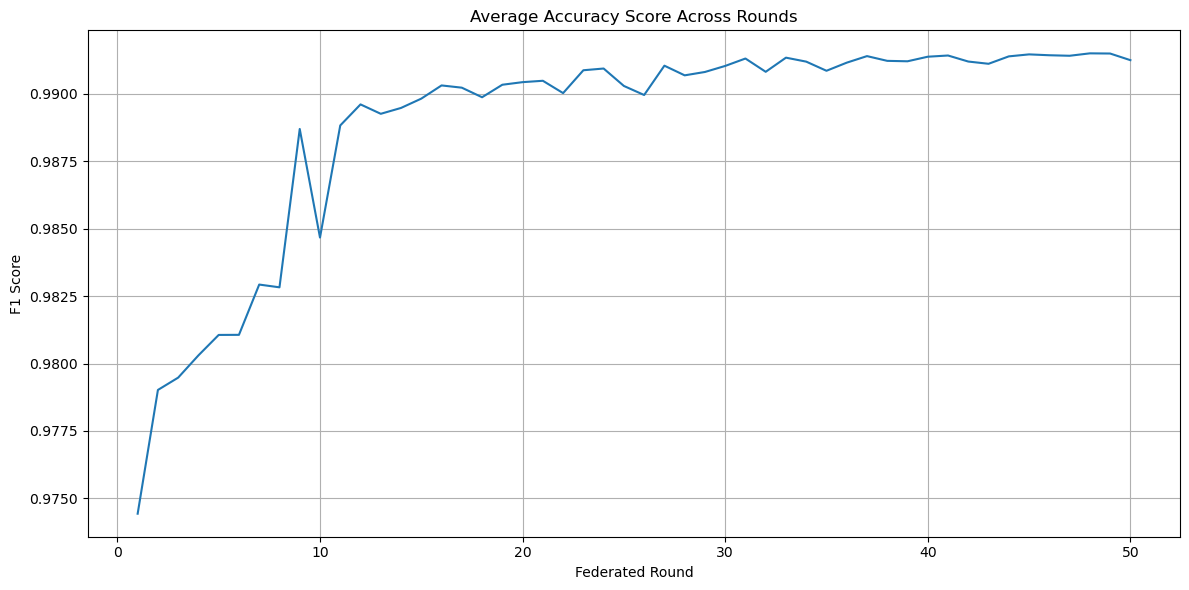

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot F1-score across rounds
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="Round", y="Accuracy", estimator='mean', ci=None)
plt.title("Average Accuracy Score Across Rounds")
plt.ylabel("F1 Score")
plt.xlabel("Federated Round")
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\saipr\AppData\Local\Temp\ipykernel_18084\3989067291.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df, x="Round", y="Precision", estimator='mean', ci=None)


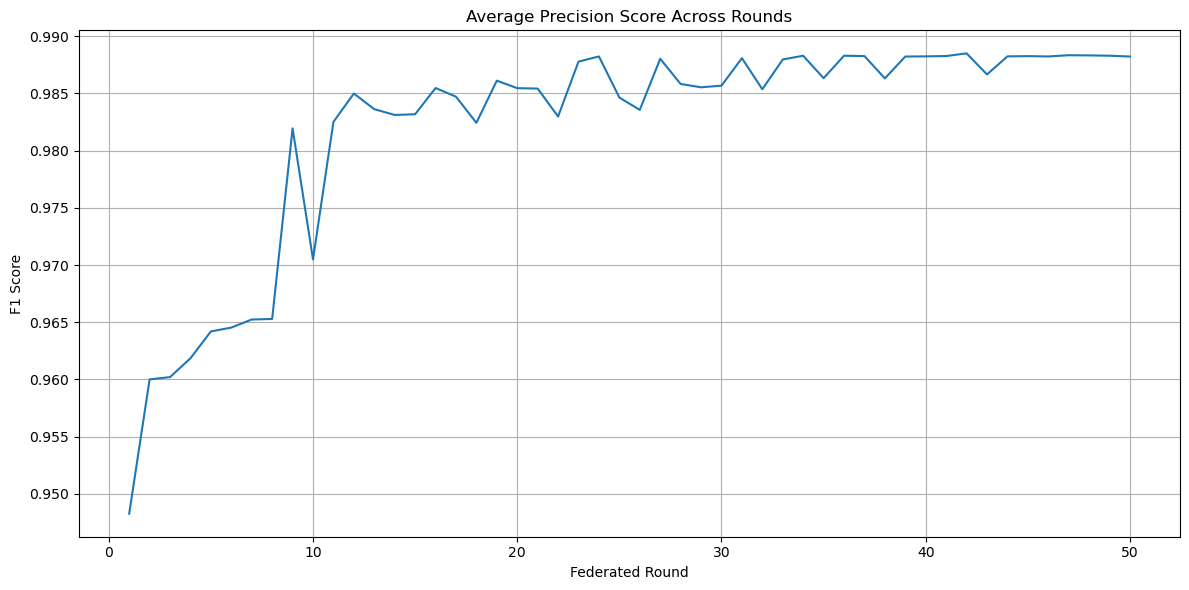

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot F1-score across rounds
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="Round", y="Precision", estimator='mean', ci=None)
plt.title("Average Precision Score Across Rounds")
plt.ylabel("F1 Score")
plt.xlabel("Federated Round")
plt.grid(True)
plt.tight_layout()
plt.show()


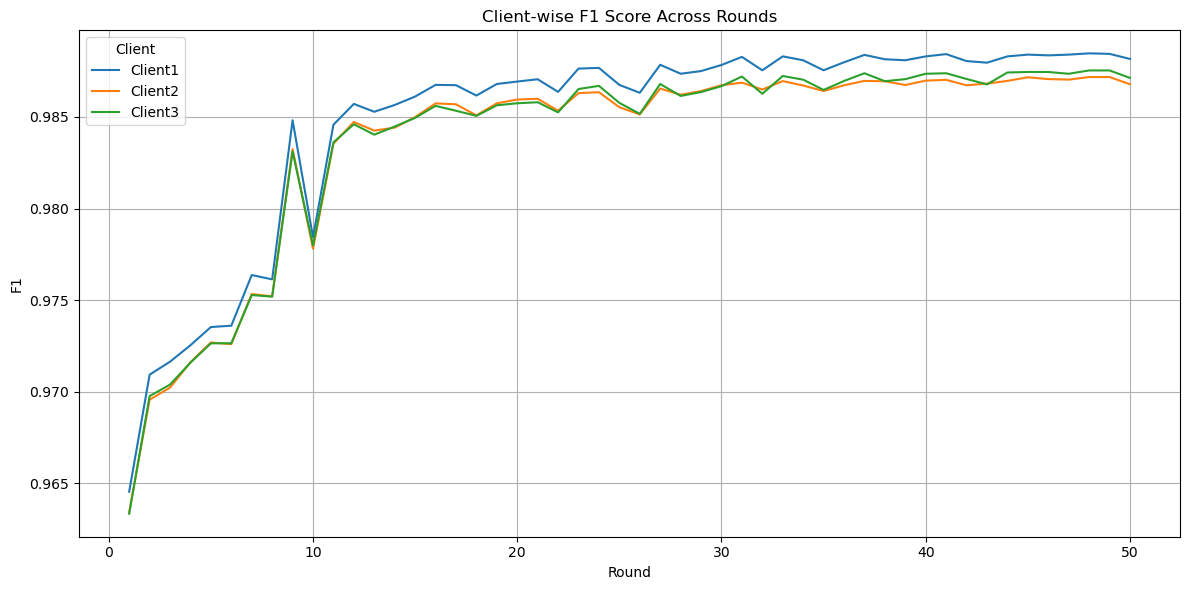

In [25]:
# Add a Client ID assuming order repeats every 3 rows
df["Client"] = ["Client1", "Client2", "Client3"] * (len(df) // 3)

# Now plot grouped by client
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="Round", y="F1", hue="Client")
plt.title("Client-wise F1 Score Across Rounds")
plt.grid(True)\\\\\\\\\\\\\\\\\\\\\
plt.tight_layout()
plt.show()


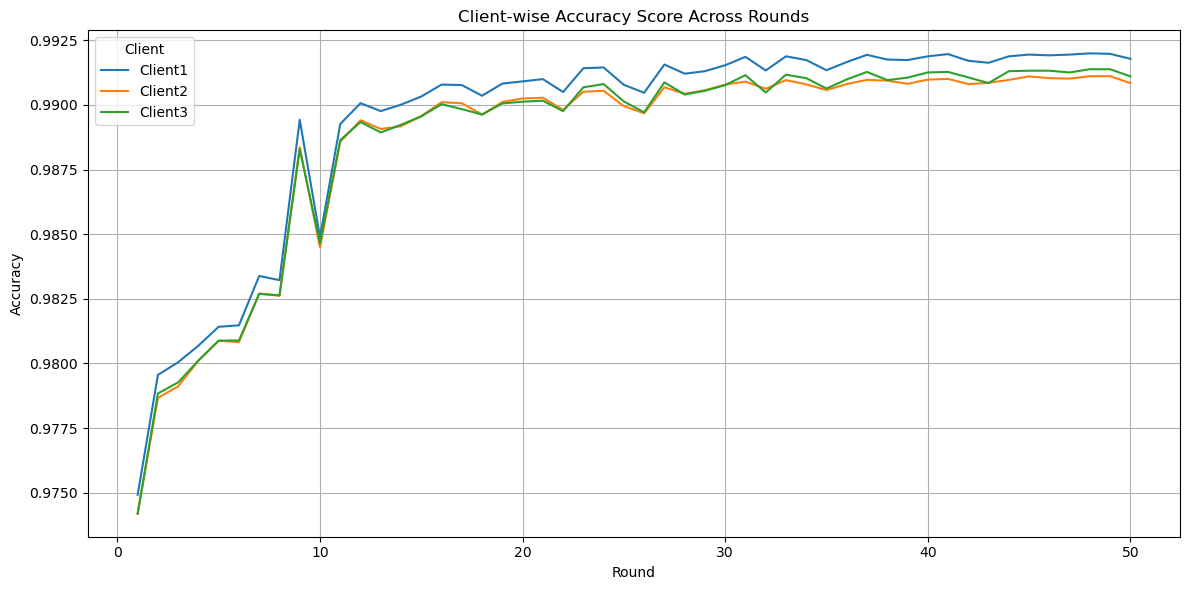

In [27]:
# Add a Client ID assuming order repeats every 3 rows
df["Client"] = ["Client1", "Client2", "Client3"] * (len(df) // 3)

# Now plot grouped by client
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="Round", y="Accuracy", hue="Client")
plt.title("Client-wise Accuracy Score Across Rounds")
plt.grid(True)
plt.tight_layout()
plt.show()


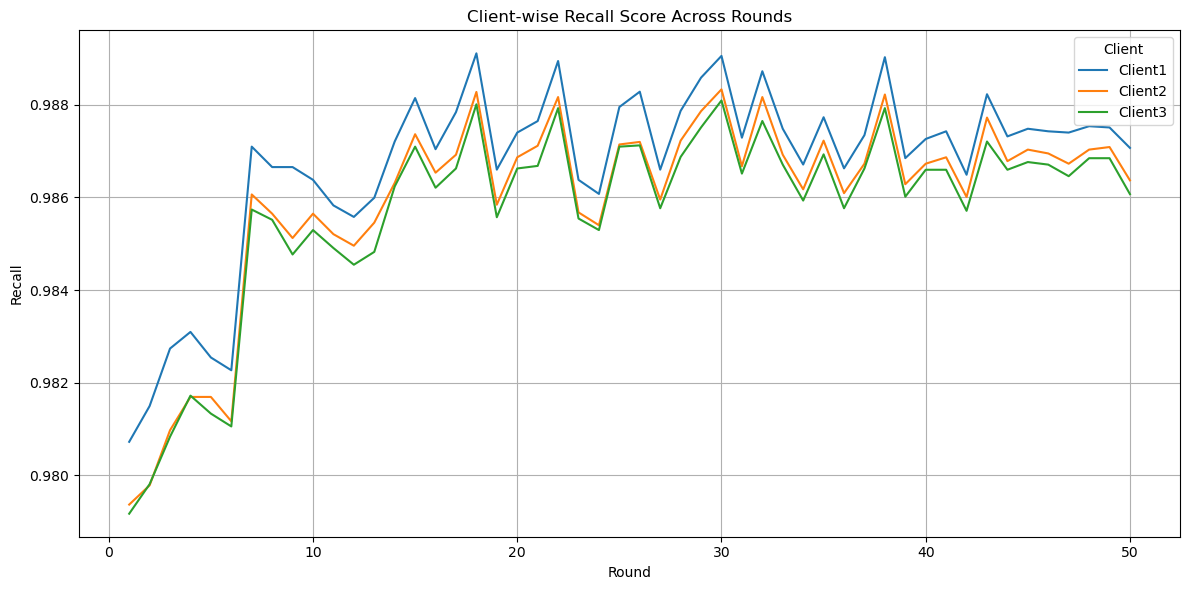

In [29]:
# Add a Client ID assuming order repeats every 3 rows
df["Client"] = ["Client1", "Client2", "Client3"] * (len(df) // 3)

# Now plot grouped by client
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="Round", y="Recall", hue="Client")
plt.title("Client-wise Recall Score Across Rounds")
plt.grid(True)
plt.tight_layout()
plt.show()


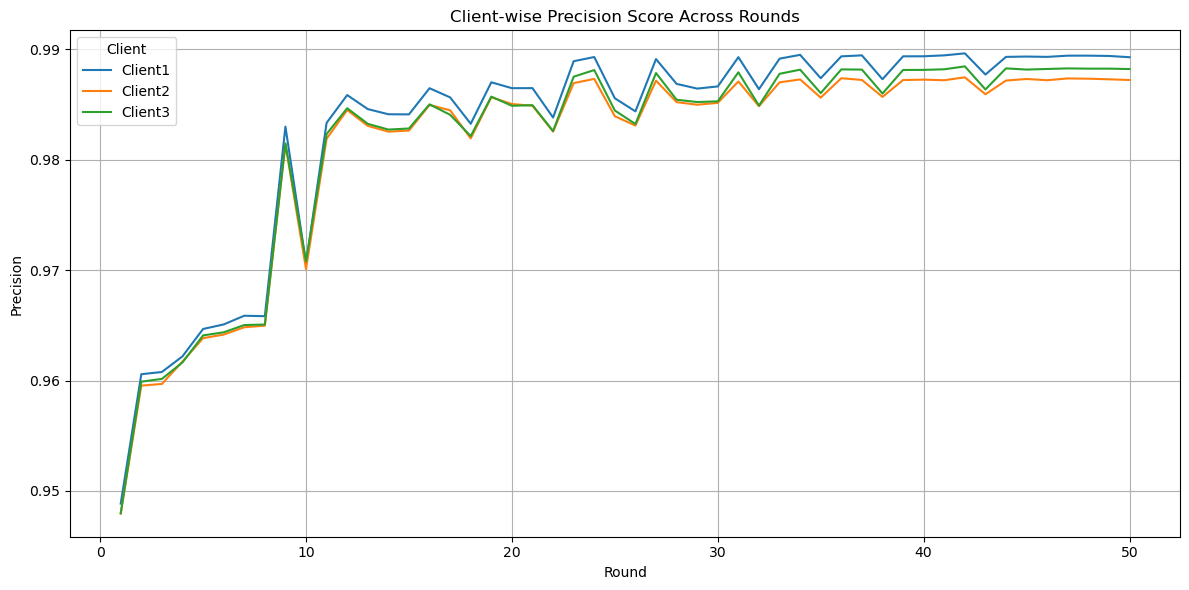

In [31]:
# Add a Client ID assuming order repeats every 3 rows
df["Client"] = ["Client1", "Client2", "Client3"] * (len(df) // 3)

# Now plot grouped by client
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="Round", y="Precision", hue="Client")
plt.title("Client-wise Precision Score Across Rounds")
plt.grid(True)
plt.tight_layout()
plt.show()


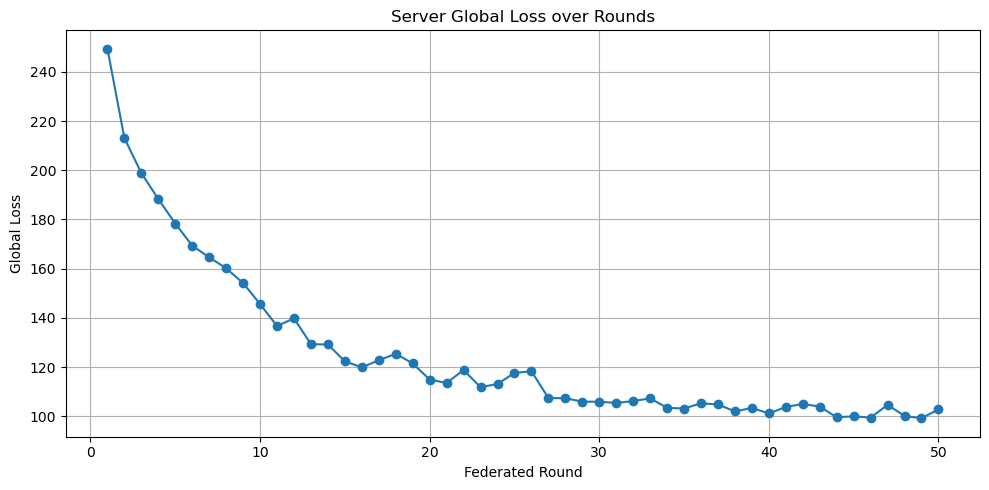

In [33]:
server_loss = [
    249.38, 213.07, 198.84, 188.29, 178.33, 169.34, 164.60, 160.15, 154.12, 145.60,
    136.68, 139.79, 129.26, 129.19, 122.32, 119.86, 122.75, 125.40, 121.46, 114.90,
    113.52, 118.79, 111.79, 113.14, 117.58, 118.32, 107.38, 107.33, 105.92, 105.89,
    105.42, 106.16, 107.27, 103.41, 103.14, 105.24, 104.79, 101.95, 103.38, 101.12,
    103.76, 105.01, 103.89,  99.58,  99.95,  99.44, 104.63, 100.12,  99.18, 102.79
]

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(server_loss)+1), server_loss, marker='o')
plt.title("Server Global Loss over Rounds")
plt.xlabel("Federated Round")
plt.ylabel("Global Loss")
plt.grid(True)
plt.tight_layout()
plt.show()


In [35]:
client_df = pd.read_csv("C:/Users/saipr/OneDrive/Documents/Deep Learning/FL-IDS Project/client_metrics_rounds_1.csv")

# Group by round to get mean accuracy/precision/recall/F1 across 3 clients
round_avg = client_df.groupby("Round").mean().reset_index()

# Add server loss
server_loss = [
    249.38, 213.07, 198.84, 188.29, 178.33, 169.34, 164.60, 160.15, 154.12, 145.60,
    136.68, 139.79, 129.26, 129.19, 122.32, 119.86, 122.75, 125.40, 121.46, 114.90,
    113.52, 118.79, 111.79, 113.14, 117.58, 118.32, 107.38, 107.33, 105.92, 105.89,
    105.42, 106.16, 107.27, 103.41, 103.14, 105.24, 104.79, 101.95, 103.38, 101.12,
    103.76, 105.01, 103.89,  99.58,  99.95,  99.44, 104.63, 100.12,  99.18, 102.79
]

round_avg["Server Loss"] = server_loss

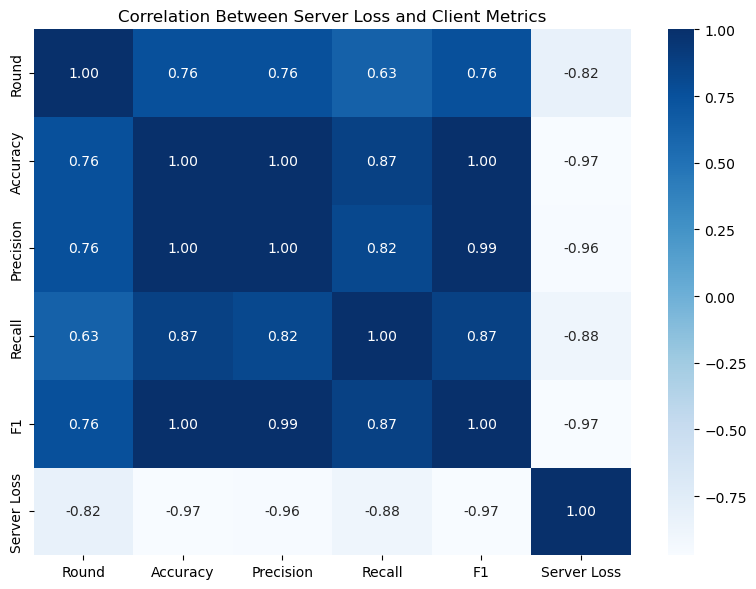

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(round_avg.corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Between Server Loss and Client Metrics")
plt.tight_layout()
plt.show()